In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Understanding the Dataset

In [2]:
#load dataset
df= pd.read_csv(r"C:\Users\RAVINDRA MANDAL\Downloads\Ola-Slides\OLA_DataSet.csv")

In [3]:
df.head(5)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


In [4]:
df.shape

(103024, 20)

In [5]:
df.info

<bound method DataFrame.info of                        Date      Time     Booking_ID        Booking_Status  \
0       2024-07-26 14:00:00  14:00:00  CNR7153255142    Canceled by Driver   
1       2024-07-25 22:20:00  22:20:00  CNR2940424040               Success   
2       2024-07-30 19:59:00  19:59:00  CNR2982357879               Success   
3        2024-07-22 3:15:00  03:15:00  CNR2395710036  Canceled by Customer   
4        2024-07-02 9:02:00  09:02:00  CNR1797421769               Success   
...                     ...       ...            ...                   ...   
103019   2024-07-31 9:06:00  09:06:00  CNR9488489435               Success   
103020  2024-07-31 15:12:00  15:12:00  CNR3151743100               Success   
103021  2024-07-31 13:59:00  13:59:00  CNR1286151233               Success   
103022  2024-07-31 14:56:00  14:56:00  CNR2027162035               Success   
103023  2024-07-31 13:57:00  13:57:00  CNR9770709721               Success   

       Customer_ID Vehicle_Type

In [10]:
df.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000
mean,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313
std,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000
25%,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000
50%,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000
75%,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000


In [6]:
#find null value
df.isnull().sum()

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                39057
Customer_Rating               39057
Vehicle Images                    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
(df.isnull().sum()/len(df))*100

Date                           0.000000
Time                           0.000000
Booking_ID                     0.000000
Booking_Status                 0.000000
Customer_ID                    0.000000
Vehicle_Type                   0.000000
Pickup_Location                0.000000
Drop_Location                  0.000000
V_TAT                         37.910584
C_TAT                         37.910584
Canceled_Rides_by_Customer    89.809171
Canceled_Rides_by_Driver      82.107082
Incomplete_Rides              37.910584
Incomplete_Rides_Reason       96.189237
Booking_Value                  0.000000
Payment_Method                37.910584
Ride_Distance                  0.000000
Driver_Ratings                37.910584
Customer_Rating               37.910584
Vehicle Images                 0.000000
dtype: float64

### 2. Handle Missing Values

In [23]:
dff=df.drop(columns=['Canceled_Rides_by_Customer','Canceled_Rides_by_Driver','Incomplete_Rides_Reason'])

In [25]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              103024 non-null  object 
 1   Time              103024 non-null  object 
 2   Booking_ID        103024 non-null  object 
 3   Booking_Status    103024 non-null  object 
 4   Customer_ID       103024 non-null  object 
 5   Vehicle_Type      103024 non-null  object 
 6   Pickup_Location   103024 non-null  object 
 7   Drop_Location     103024 non-null  object 
 8   V_TAT             63967 non-null   float64
 9   C_TAT             63967 non-null   float64
 10  Incomplete_Rides  63967 non-null   object 
 11  Booking_Value     103024 non-null  int64  
 12  Payment_Method    63967 non-null   object 
 13  Ride_Distance     103024 non-null  int64  
 14  Driver_Ratings    63967 non-null   float64
 15  Customer_Rating   63967 non-null   float64
 16  Vehicle Images    10

In [26]:
dfg=dff.dropna()

In [27]:
dfg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63967 entries, 1 to 103023
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              63967 non-null  object 
 1   Time              63967 non-null  object 
 2   Booking_ID        63967 non-null  object 
 3   Booking_Status    63967 non-null  object 
 4   Customer_ID       63967 non-null  object 
 5   Vehicle_Type      63967 non-null  object 
 6   Pickup_Location   63967 non-null  object 
 7   Drop_Location     63967 non-null  object 
 8   V_TAT             63967 non-null  float64
 9   C_TAT             63967 non-null  float64
 10  Incomplete_Rides  63967 non-null  object 
 11  Booking_Value     63967 non-null  int64  
 12  Payment_Method    63967 non-null  object 
 13  Ride_Distance     63967 non-null  int64  
 14  Driver_Ratings    63967 non-null  float64
 15  Customer_Rating   63967 non-null  float64
 16  Vehicle Images    63967 non-null  object 
dt

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [38]:
df['Booking_Status'].value_counts()

Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64

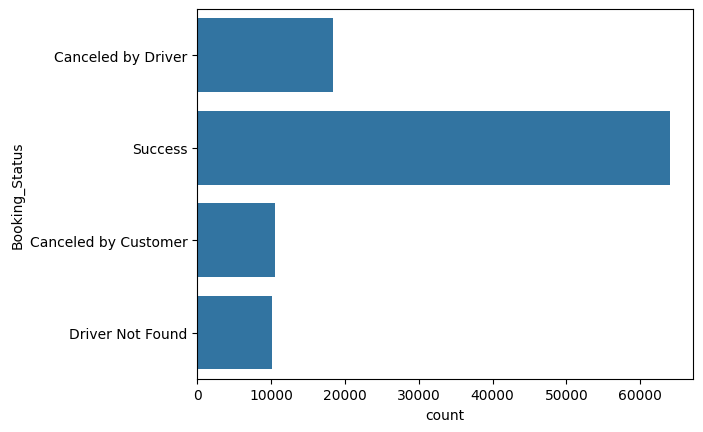

In [41]:
sns.countplot(df['Booking_Status'])
plt.show()

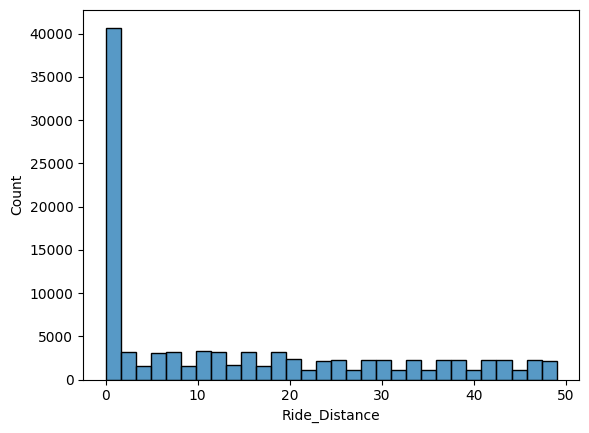

In [7]:
sns.histplot(df['Ride_Distance'], bins=30)
plt.show()

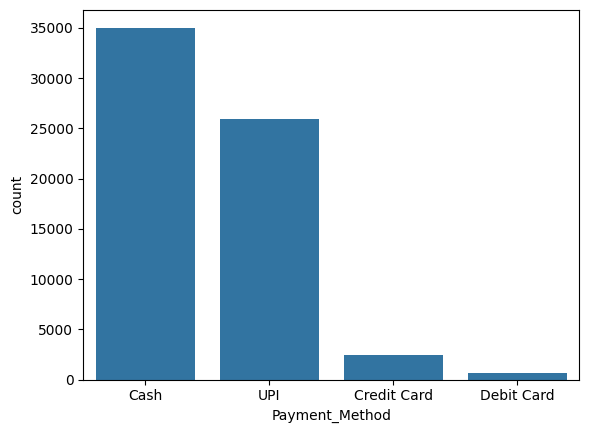

In [8]:
sns.countplot(x='Payment_Method', data=df)
plt.show()

In [9]:
df.corr(numeric_only=True)

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
V_TAT,1.000000,0.000249,-0.003671,-0.011204,-0.002300,0.000574
C_TAT,0.000249,1.000000,-0.004443,0.000074,-0.002815,0.001015
Booking_Value,-0.003671,-0.004443,1.000000,0.000492,-0.001327,0.006231
Ride_Distance,-0.011204,0.000074,0.000492,1.000000,-0.007235,0.009871
Driver_Ratings,-0.002300,-0.002815,-0.001327,-0.007235,1.000000,-0.002807
Customer_Rating,0.000574,0.001015,0.006231,0.009871,-0.002807,1.000000


### Handel the Outlier

<Axes: ylabel='Ride_Distance'>

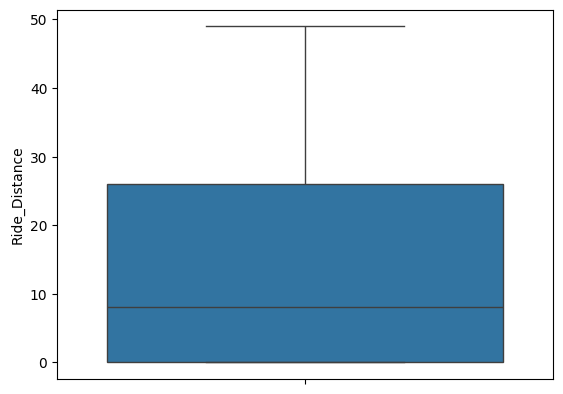

In [11]:
sns.boxplot(df['Ride_Distance'])

### Data Preprocessing
we prepare the data for analysis or machine learning models.

### Feature Selection
* Age
* Ride Distance
* Booking Value

### Encoding Categorical Data
* Vehicle_Type
* Auto
* Mini
* Prime

In [15]:
dff=pd.get_dummies(df['Vehicle_Type'])
dff

,Auto,Bike,Mini,Prime Plus,Prime SUV,Prime Sedan,eBike
0,False,False,False,False,False,True,False
1,False,True,False,False,False,False,False
2,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True
4,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
103019,False,False,False,True,False,False,False
103020,True,False,False,False,False,False,False
103021,False,False,False,False,True,False,False
103022,False,False,False,False,False,False,True


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(dff)